# **Upload Dataset**

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


# **Load Dataset**

In [2]:
import pandas as pd

df = pd.read_csv('Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# **Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

# **Dataset Information**

In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


# **Customer Distribution Visualization**

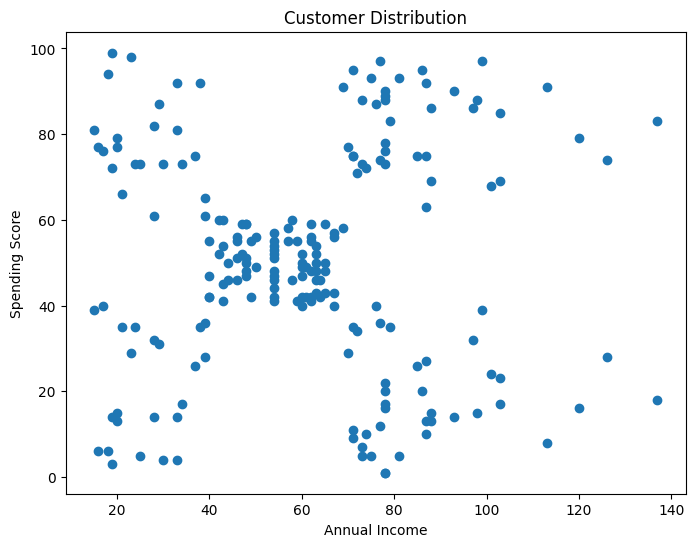

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(df['Annual Income (k$)'],
            df['Spending Score (1-100)'])

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Distribution')

plt.show()

# **Feature Selection**

In [6]:
X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

# **Elbow Method**

In [7]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# **Elbow Graph**

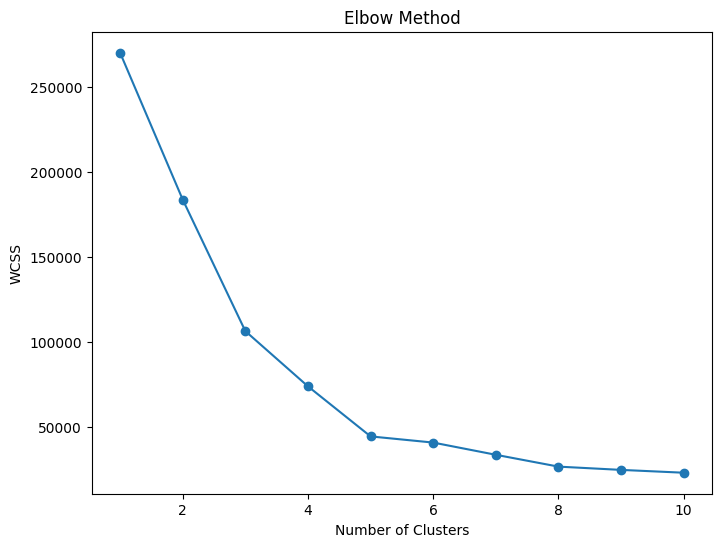

In [8]:
plt.figure(figsize=(8,6))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

# **Train Model**

In [9]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

# **Visualization**

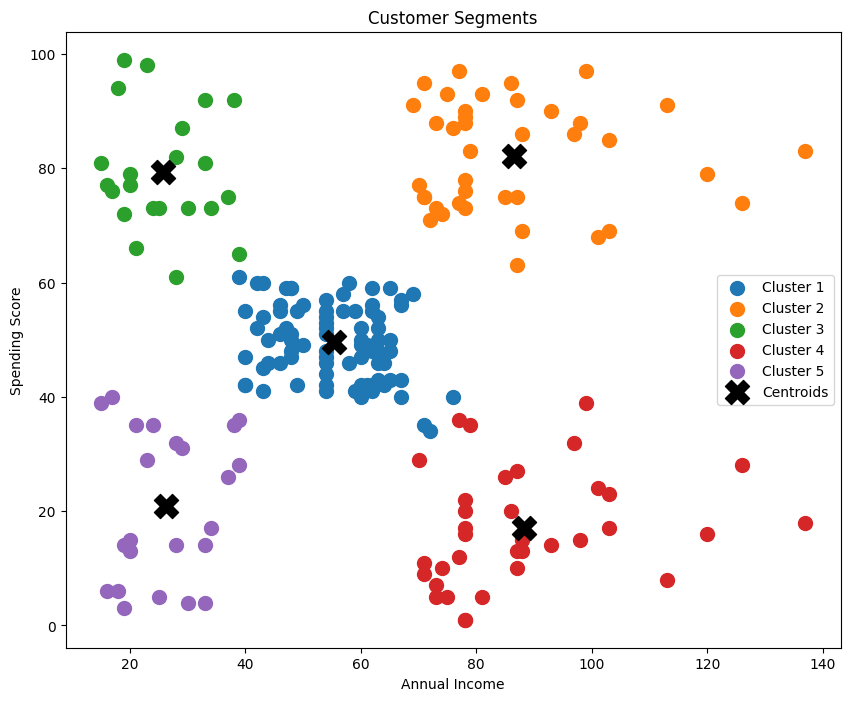

In [10]:
plt.figure(figsize=(10,8))

plt.scatter(X.iloc[y_kmeans == 0, 0],
            X.iloc[y_kmeans == 0, 1],
            s=100,
            label='Cluster 1')

plt.scatter(X.iloc[y_kmeans == 1, 0],
            X.iloc[y_kmeans == 1, 1],
            s=100,
            label='Cluster 2')

plt.scatter(X.iloc[y_kmeans == 2, 0],
            X.iloc[y_kmeans == 2, 1],
            s=100,
            label='Cluster 3')

plt.scatter(X.iloc[y_kmeans == 3, 0],
            X.iloc[y_kmeans == 3, 1],
            s=100,
            label='Cluster 4')

plt.scatter(X.iloc[y_kmeans == 4, 0],
            X.iloc[y_kmeans == 4, 1],
            s=100,
            label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300,
            c='black',
            marker='X',
            label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.legend()

plt.show()